# Scenario: Predicting Patient Recovery Time

A hospital research team wants to build a machine learning model to predict patient recovery time (in days) after surgery.

They collect data from 1,000 patients, including the following features:

- Age of the patient  
- Number of hours of post-surgery physiotherapy per week  
- Pre-existing health condition severity (numeric score)  
- Length of hospital stay (in days)  
- Average sleep hours during recovery  

Since recovery time is a continuous numeric value, the team decides to use Linear Regression.

To evaluate the model’s performance and ensure it generalizes well, they apply 5-Fold Cross-Validation using R² (R-squared) as the evaluation metric.

--------------------------------------------------

## Questions for Learners

**Part A:**  
Why is Linear Regression an appropriate choice for this problem?

**Part B:**  
Why can't accuracy be used as an evaluation metric in this scenario?

**Part C:**  
What does an R² value close to 1 indicate about the model?

**Part D:**  
Why is 5-Fold Cross-Validation better than evaluating the model on a single train-test split?

In [54]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np

In [55]:
X,y = make_regression(n_samples = 1000,n_features = 5 , noise = 15 ,random_state = 42 )


In [56]:
model = LinearRegression()
#define 5 fold cv
kf= KFold(n_splits = 5 , shuffle = True , random_state = 42)
# Evaluate this on r2
scores = cross_val_score(model , X , y , cv = kf , scoring = 'r2')

print("R2 scores for each fold :",scores.round(3))
print("Mean R2 : ",scores.mean().round(3))

R2 scores for each fold : [0.937 0.945 0.945 0.947 0.947]
Mean R2 :  0.944


In [57]:
if scores.std() < 0.05 :
    print("Model is stable acorss folds ")
else :
    print("Model perfromance varies across folds investiagte further")

Model is stable acorss folds 


# Scenario: Predicting Patient Recovery Time

A hospital research team wants to build a machine learning model to predict patient recovery time (in days) after surgery.

They collect data from 1,000 patients, including the following features:

- Age of the patient  
- Number of hours of post-surgery physiotherapy per week  
- Pre-existing health condition severity (numeric score)  
- Length of hospital stay (in days)  
- Average sleep hours during recovery  

Since recovery time is a continuous numeric value, the team decides to use **Linear Regression**.

To evaluate the model's performance and ensure it generalizes well, they apply **5-Fold Cross-Validation** using **R² (R-squared)** as the evaluation metric.

In [58]:
# Import required libraries
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

np.random.seed(42)

n_samples = 1000

# Features
age = np.random.randint(20, 80, n_samples)  # Age between 20–80
physio_hours = np.random.randint(1, 10, n_samples)  # Physiotherapy hours per week
severity_score = np.random.randint(1, 10, n_samples)  # Health condition severity (1–10)
hospital_stay = np.random.randint(3, 20, n_samples)  # Length of stay in days
sleep_hours = np.random.uniform(4, 9, n_samples)  # Average sleep hours

# Stack features into X
X = np.column_stack((age, physio_hours, severity_score, hospital_stay, sleep_hours))


noise = np.random.normal(0, 5, n_samples)

y = (
    0.3 * age
    - 1.5 * physio_hours
    + 2.0 * severity_score
    + 0.8 * hospital_stay
    - 1.2 * sleep_hours
    + noise
)



model = LinearRegression()


kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='r2')


print("R2 scores for each fold:", scores.round(3))
print("Mean R2:", round(scores.mean(), 3))
print("Standard Deviation:", round(scores.std(), 3))



if scores.std() < 0.05:
    print("Model is stable across folds")
else:
    print("Model performance varies across folds. Investigate further.")

R2 scores for each fold: [0.805 0.759 0.768 0.794 0.748]
Mean R2: 0.775
Standard Deviation: 0.022
Model is stable across folds


Scenario: Predicting Student Exam Performance
A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
- Number of study hours per week
- Attendance percentage in lectures
- Prior GPA (Grade Point Average)
- Participation in group projects (numeric engagement score)
- Average sleep hours during exam preparation
They collect data from 800 students across different departments and decide to use Linear Regression.
To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [59]:
X,y = make_regression(n_samples = 800,n_features = 5 , noise = 15 ,random_state = 42 )


In [60]:
model = LinearRegression()
#define 5 fold cv
kf= KFold(n_splits = 5 , shuffle = True , random_state = 42)
# Evaluate this on r2
scores = cross_val_score(model , X , y , cv = kf , scoring = 'r2')

print("R2 scores for each fold :",scores.round(3))
print("Mean R2 : ",scores.mean().round(3))

R2 scores for each fold : [0.987 0.988 0.989 0.988 0.988]
Mean R2 :  0.988


In [61]:
if scores.std() < 0.05 :
    print("Model is stable acorss folds ")
else :
    print("Model perfromance varies across folds investiagte further")

Model is stable acorss folds 


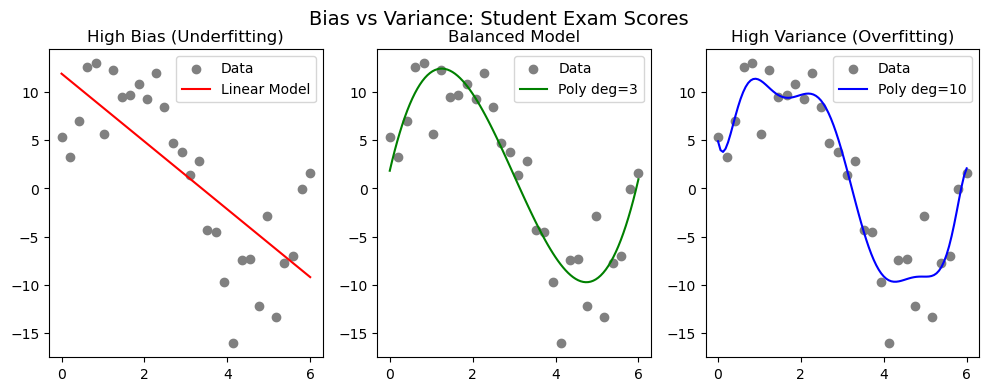

In [62]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different 
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, study hours vs exam scores (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  # exam scores with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

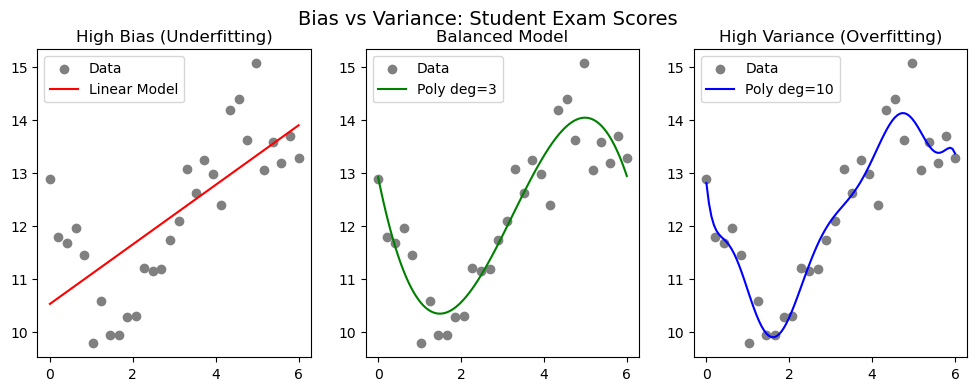

In [63]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different 
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset --
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # training hours
y = (12 - 2*np.sin(X)).ravel() + np.random.normal(scale=0.5, size=30)  
# sprint times (lower is better)

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

# Scenario: Package Delivery System

A logistics company wants to build a machine learning model to optimize package delivery.

They collect data about each package, including:

- Size: Small, Medium, Large
- Priority: Low, Medium, High

Since machine learning models work with numbers (not text labels), the company decides to use Label Encoding to convert these categories into numeric values.

Example encoding:

Size:
Small = 2  
Medium = 1  
Large = 0  

Priority:
Low = 1  
Medium = 2  
High = 0  

The company also checks the mapping and decodes the numbers back into the original labels to ensure correctness.

--------------------------------------------------

Questions for Learners:

Part A:
Why does the company need to convert categorical values like Small, Medium, Large into numbers before training a model?

Part B:
If the encoded values are 0, 1, 2, does the order (for example, Large = 0, Medium = 1, Small = 2) matter for all models? Why or why not?

Part C:
How can the company decode the numeric values back into the original labels after prediction?

Part D:
Suppose the company adds a new category "Extra Large." How would LabelEncoder handle this, and what challenge might arise if the model was already trained?

In [64]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


In [65]:
data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

In [66]:
le_size = LabelEncoder()
data["Encoded_Size"] = le_size.fit_transform(data["Size"])

le_priority = LabelEncoder()
data["Priority_Encoded"] = le_priority.fit_transform(data["Priority"])


In [67]:
print("Size mapping : ",dict(zip(le_size.classes_,le_size.transform(le_size.classes_))))
print("Priority mapping : ",dict(zip(le_priority.classes_,le_priority.transform(le_priority.classes_))))

Size mapping :  {'Large': np.int64(0), 'Medium': np.int64(1), 'Small': np.int64(2)}
Priority mapping :  {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [68]:
decoded_size = le_size.inverse_transform([0,1,2])
print("Decoded Size :",decoded_size)

Decoded Size : ['Large' 'Medium' 'Small']


In [69]:
print("Encoded DataFrame : ")
print(data)

Encoded DataFrame : 
     Size Priority  Encoded_Size  Priority_Encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0


# Scenario: Restaurant Ordering System

A restaurant wants to build a machine learning model to predict order preparation time.

They collect data about each order, including:

- Meal Type: Breakfast, Lunch, Dinner
- Spice Level: Mild, Medium, Hot

Since machine learning models cannot directly work with text labels, the restaurant uses Label Encoding to convert these categories into numbers.

Example Encoding:

Meal Type:
Breakfast = 0  
Lunch = 1  
Dinner = 2  

Spice Level:
Mild = 0  
Medium = 1  
Hot = 2  

After encoding, the dataset becomes numerical and can be used to train a model.

--------------------------------------------------

Questions:

1. Is Label Encoding appropriate for Meal Type? Why or why not?
2. Is Spice Level an ordinal or nominal feature?
3. What problem might arise if the model interprets Dinner (2) as greater than Breakfast (0)?
4. When would One-Hot Encoding be a better choice?

In [70]:
data = {
    "Order_ID": range(1, 11),
    "Meal_Type": [
        "Breakfast", "Lunch", "Dinner", "Lunch", "Dinner",
        "Breakfast", "Lunch", "Dinner", "Breakfast", "Lunch"
    ],
    "Spice_Level": [
        "Mild", "Medium", "Hot", "Mild", "Medium",
        "Hot", "Hot", "Mild", "Medium", "Medium"
    ],
    "Preparation_Time": [10, 25, 40, 20, 35, 15, 30, 28, 12, 22]
}

df = pd.DataFrame(data)


In [71]:
le_meal = LabelEncoder()
df["Encoded_Meal_Type"] = le_meal.fit_transform(df["Meal_Type"])

le_spice = LabelEncoder()
df["Encoded_Spice_Level"] = le_spice.fit_transform(df["Spice_Level"])


In [72]:
print(df)

   Order_ID  Meal_Type Spice_Level  Preparation_Time  Encoded_Meal_Type  \
0         1  Breakfast        Mild                10                  0   
1         2      Lunch      Medium                25                  2   
2         3     Dinner         Hot                40                  1   
3         4      Lunch        Mild                20                  2   
4         5     Dinner      Medium                35                  1   
5         6  Breakfast         Hot                15                  0   
6         7      Lunch         Hot                30                  2   
7         8     Dinner        Mild                28                  1   
8         9  Breakfast      Medium                12                  0   
9        10      Lunch      Medium                22                  2   

   Encoded_Spice_Level  
0                    2  
1                    1  
2                    0  
3                    2  
4                    1  
5                    0  

In [73]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


data = {
    "Patient_ID": ["P001", "P002", "P003"],
    "Blood_Type": ["O+", "A+", "B+"],
    "Age": [45, 52, 38],
    "Risk": ["Low", "High", "Medium"]
}

df = pd.DataFrame(data)

print(df)

  Patient_ID Blood_Type  Age    Risk
0       P001         O+   45     Low
1       P002         A+   52    High
2       P003         B+   38  Medium


In [74]:
encoder = OneHotEncoder(sparse_output = False)

In [75]:
encoded_array = encoder.fit_transform(df[["Blood_Type"]])

In [76]:
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(["Blood_Type"])
)

In [77]:
df = pd.concat([df, encoded_df], axis=1)
df.drop("Blood_Type", axis=1, inplace=True)

print(df)

  Patient_ID  Age    Risk  Blood_Type_A+  Blood_Type_B+  Blood_Type_O+
0       P001   45     Low            0.0            0.0            1.0
1       P002   52    High            1.0            0.0            0.0
2       P003   38  Medium            0.0            1.0            0.0


# Scenario: Employee Training & Satisfaction Survey

A company conducts a survey to understand how employee education level and job satisfaction affect performance.

They collect the following data:
- Education: High School, Bachelor, Master, PhD
- Satisfaction: Poor, Average, Good, Excellent

Since these categories have a natural order (PhD is higher than Bachelor, Excellent is better than Good), the company decides to use Ordinal Encoding.

Custom ordering defined:

Education:
High School = 0  
Bachelor = 1  
Master = 2  
PhD = 3  

Satisfaction:
Poor = 0  
Average = 1  
Good = 2  
Excellent = 3  

They also compare this with manual dictionary mapping to ensure consistency.

--------------------------------------------------

Questions:

Part A:
Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered categories like education level?

Part B:
If the company encoded PhD = 0 and High School = 3, what problem might arise in interpreting the model?

Part C:
How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?

Part D:
Suppose the company adds a new satisfaction level "Outstanding". How should they update their encoding scheme to keep the order meaningful?

In [78]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

In [79]:


# Step 1: Sample survey data

data = pd.DataFrame({
    'Education': ['Bachelor', 'PhD', 'Master', 'High School'],
    'Satisfaction': ['Good', 'Excellent', 'Poor', 'Average']
})

# Step 2: Define custom ordering

education_order = [['High School', 'Bachelor', 'Master', 'PhD']]
satisfaction_order = [['Poor', 'Average', 'Good', 'Excellent']]


# Step 3: Use OrdinalEncoder for custom ordering

edu_encoder = OrdinalEncoder(categories=education_order)
data['Education_Encoded'] = edu_encoder.fit_transform(data[['Education']])

sat_encoder = OrdinalEncoder(categories=satisfaction_order)
data['Satisfaction_Encoded'] = sat_encoder.fit_transform(data[['Satisfaction']])


# Step 4: Alternative manual mapping with dictionaries

education_map = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

satisfaction_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3
}

data['Education_Manual'] = data['Education'].map(education_map)
data['Satisfaction_Manual'] = data['Satisfaction'].map(satisfaction_map)


# Final Output

print(data)

     Education Satisfaction  Education_Encoded  Satisfaction_Encoded  \
0     Bachelor         Good                1.0                   2.0   
1          PhD    Excellent                3.0                   3.0   
2       Master         Poor                2.0                   0.0   
3  High School      Average                0.0                   1.0   

   Education_Manual  Satisfaction_Manual  
0                 1                    2  
1                 3                    3  
2                 2                    0  
3                 0                    1  


In [80]:
# Scenario: Patient Health Monitoring
# A hospital wants to analyze patient records to understand how disease severity and recovery 
# satisfaction affect treatment outcomes.
# They collect data such as:
# - Disease Severity: Mild, Moderate, Severe, Critical
# - Recovery Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., Critical is worse than Mild, Excellent is 
# better than Poor), the hospital uses Ordinal Encoding to convert them into numbers that respect this
#  ranking.
# They define custom ordering:
# - Disease Severity → Mild (0), Moderate (1), Severe (2), Critical (3)
# - Recovery Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

In [ ]:
# Scenario: Online Food Delivery App
# An online food delivery company wants to build a machine learning model to predict delivery time based
#  on the type of cuisine ordered.
# They collect data such as:
# - Cuisine Type: Italian, Chinese, Indian, Mexican
# Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
#  Encoding.
# This method creates a new column for each cuisine type:
# - Italian → [1, 0, 0, 0]
# - Chinese → [0, 1, 0, 0]
# - Indian → [0, 0, 1, 0]
# - Mexican → [0, 0, 0, 1]
# They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
#  the results easier to read and print for analysis.

# Questions for Learners
# Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?
# Part B: What does sparse=False do, and why might it be useful in this scenario?
# Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?
# Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
#  how might they solve it?

In [81]:
# how might they solve it?

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# ----------------------------------
# Scenario: Online Food Delivery App
# ----------------------------------

# Step 1: Sample cuisine data
orders = pd.DataFrame({
    'Cuisine': ['Italian', 'Chinese', 'Indian', 'Mexican', 'Chinese', 'Italian']
})

# Step 2: Apply OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(orders[['Cuisine']])

# Step 3: Convert encoded array back into a DataFrame for readability
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.categories_[0]
)

# Step 4: Combine with original data
final_data = pd.concat([orders, encoded_df], axis=1)

# Step 5: Display results
print(final_data)

   Cuisine  Chinese  Indian  Italian  Mexican
0  Italian      0.0     0.0      1.0      0.0
1  Chinese      1.0     0.0      0.0      0.0
2   Indian      0.0     1.0      0.0      0.0
3  Mexican      0.0     0.0      0.0      1.0
4  Chinese      1.0     0.0      0.0      0.0
5  Italian      0.0     0.0      1.0      0.0
